# Global Trade Matchmaking Project
## Data Analysis & Exploratory Data Analysis (EDA)
This notebook performs exploratory analysis on the commodity trade dataset used for the Swipe-to-Export matchmaking system.

## 1. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [8]:
df = pd.read_csv('/content/sample_data/commodity_trade_statistics_final.csv', header=1)
df.head()

,country_or_area,year,commodity,flow,trade_usd
0,China,2016,"Animals, live, except farm animals",Import,87264965
1,China,2016,"Animals, live, except farm animals",Export,55747455
2,China,2015,"Animals, live, except farm animals",Import,83102354
3,China,2015,"Animals, live, except farm animals",Export,37526715
4,China,2014,"Animals, live, except farm animals",Import,118595882


## 3. Select Relevant Columns

In [9]:
df = df[['country_or_area','year','commodity','flow','trade_usd']]
df.head()

,country_or_area,year,commodity,flow,trade_usd
0,China,2016,"Animals, live, except farm animals",Import,87264965
1,China,2016,"Animals, live, except farm animals",Export,55747455
2,China,2015,"Animals, live, except farm animals",Import,83102354
3,China,2015,"Animals, live, except farm animals",Export,37526715
4,China,2014,"Animals, live, except farm animals",Import,118595882


## 4. Dataset Overview

In [10]:
print('Dataset shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Dataset shape: (2603, 5)

Column types:
country_or_area    object
year                int64
commodity          object
flow               object
trade_usd           int64
dtype: object

Missing values:
country_or_area    0
year               0
commodity          0
flow               0
trade_usd          0
dtype: int64


## 5. Data Cleaning

In [11]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(2603, 5)

## 6. Summary Statistics

In [12]:
df.describe()

,year,trade_usd
count,2603.000000,2.603000e+03
mean,2013.996158,1.283144e+08
std,1.413393,4.342373e+08
min,2012.000000,1.600000e+01
25%,2013.000000,6.158985e+05
50%,2014.000000,9.347468e+06
75%,2015.000000,7.018073e+07
max,2016.000000,7.754818e+09


## 7. Export vs Import Distribution

In [13]:
flow_counts = df['flow'].value_counts()
flow_counts

,count
flow,
Export,1319
Import,1284


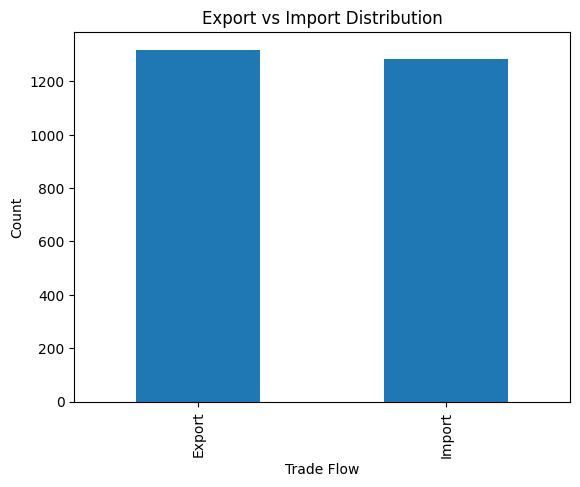

In [14]:
flow_counts.plot(kind='bar')
plt.title('Export vs Import Distribution')
plt.xlabel('Trade Flow')
plt.ylabel('Count')
plt.show()

## 8. Top Exporting Countries

In [15]:
exports = df[df['flow']=='Export']
top_exporters = exports.groupby('country_or_area')['trade_usd'].sum().sort_values(ascending=False).head(10)
top_exporters

,trade_usd
country_or_area,
China,59907305008
Germany,59515981694
India,43396343828
USA,11629239567
United Arab Emirates,1552496590
Japan,649327525


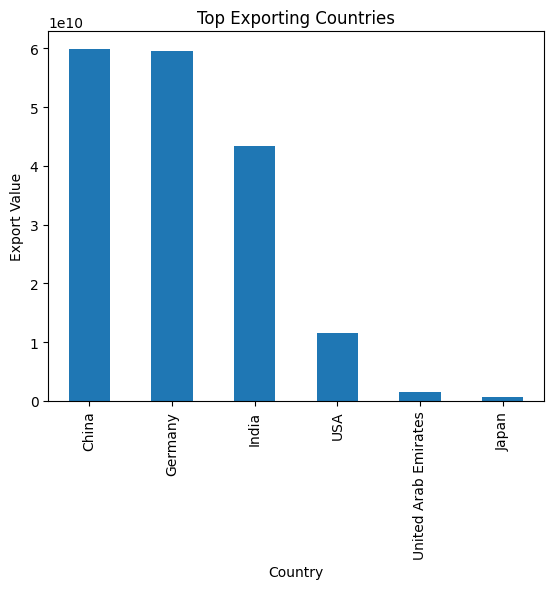

In [16]:
top_exporters.plot(kind='bar')
plt.title('Top Exporting Countries')
plt.xlabel('Country')
plt.ylabel('Export Value')
plt.show()

## 9. Top Importing Countries

In [17]:
imports = df[df['flow']=='Import']
top_importers = imports.groupby('country_or_area')['trade_usd'].sum().sort_values(ascending=False).head(10)
top_importers

,trade_usd
country_or_area,
Germany,73532293306
China,50567214287
Japan,16839881413
USA,10697318590
United Arab Emirates,4497286186
India,1217769516


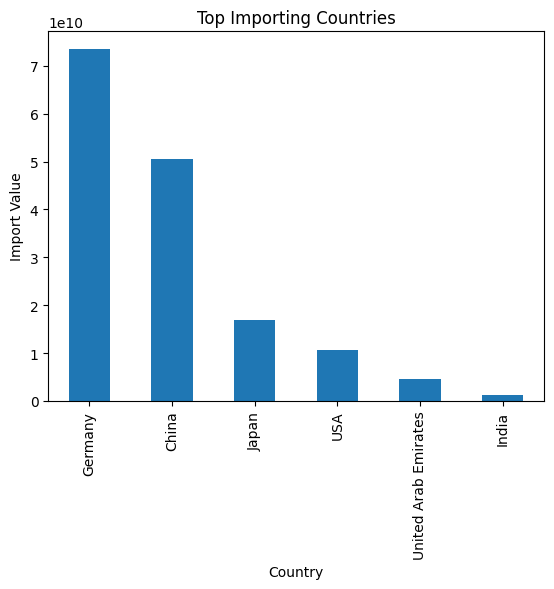

In [18]:
top_importers.plot(kind='bar')
plt.title('Top Importing Countries')
plt.xlabel('Country')
plt.ylabel('Import Value')
plt.show()

## 10. Most Traded Commodities

In [19]:
top_products = df.groupby('commodity')['trade_usd'].sum().sort_values(ascending=False).head(10)
top_products

,trade_usd
commodity,
"Rice, semi-milled or wholly milled",57593231398
"Cheese except fresh, grated, processed or blue-veined",32564788438
"Coffee, not roasted, not decaffeinated",30656458660
"Fruits, fresh nes",11604781342
Milk and cream powder unsweetened < 1.5% fat,11106977289
Milk powder < 1.5% fat,10625165714
Milk not concentrated nor sweetened 1-6% fat,10314122120
"Bananas, including plantains, fresh or dried",9780785630
"Apples, fresh",9300980394


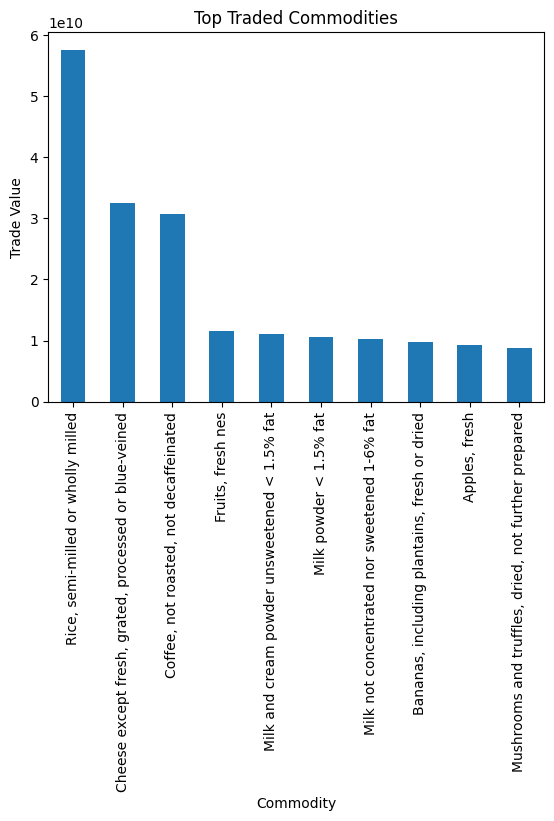

In [20]:
top_products.plot(kind='bar')
plt.title('Top Traded Commodities')
plt.xlabel('Commodity')
plt.ylabel('Trade Value')
plt.show()

## 11. Commodity Search Example

In [21]:
def search_commodity(keyword):
    keyword = keyword.lower()
    options = [c for c in df['commodity'].unique() if keyword in c.lower()]
    return options

search_commodity('coffee')

['Coffee, not roasted, not decaffeinated',
 'Coffee, not roasted, decaffeinated',
 'Coffee, roasted, decaffeinated']

## 12. Key Insights
- Identify major exporters and importers
- Identify high-demand commodities
- Understand trade patterns used for matchmaking
- These insights help build the ML recommendation system